# M3 Multi-Item Association Rules — Olist E-commerce Recommendation

Ready-to-run notebook for Member 3.

This notebook starts from Member 2's PostgreSQL DWH views:
- `v_baskets_product`
- `v_baskets_category`
- `v_orders_with_holiday`

It produces Apriori, FP-Growth, ECLAT-style rules, sensitivity results, holiday/seasonal EDA, and ranked rules for M5.

## 1. Setup imports and project folders

In [1]:
import os
import time
from pathlib import Path
from getpass import getpass
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

from scipy.stats import chi2_contingency

print("Imports are working.")

Imports are working.


This cell finds the project root and creates output folders, even if the notebook is inside `notebooks/`.

In [2]:
# Detect project root robustly
cwd = Path.cwd()
project_root = cwd

for candidate in [cwd] + list(cwd.parents):
    if (candidate / "M2_DWH").exists() or (candidate / "olist_dwh.dump").exists():
        project_root = candidate
        break

os.chdir(project_root)

OUTPUT_RULES = Path("outputs/rules_multi_item")
OUTPUT_FIGURES = Path("outputs/figures_multi_item")
OUTPUT_RULES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

print("Current working directory:", Path.cwd())
print("Rules output folder:", OUTPUT_RULES.resolve())
print("Figures output folder:", OUTPUT_FIGURES.resolve())

Current working directory: C:\Users\moh75\olist-recommendation-system
Rules output folder: C:\Users\moh75\olist-recommendation-system\outputs\rules_multi_item
Figures output folder: C:\Users\moh75\olist-recommendation-system\outputs\figures_multi_item


## 2. Connect to PostgreSQL DWH

In [3]:
password = os.environ.get("PGPASSWORD") or getpass("Enter PostgreSQL password for user postgres: ")

url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password=password,
    host="localhost",
    port=5432,
    database="olist_dwh"
)

engine = create_engine(url)

pd.read_sql("SELECT COUNT(*) AS n FROM v_baskets_category", engine)

,n
0,95146


Check that the three M3 views exist and return the expected row counts.

In [4]:
views_check = {
    "v_baskets_product": "SELECT COUNT(*) AS n FROM v_baskets_product",
    "v_baskets_category": "SELECT COUNT(*) AS n FROM v_baskets_category",
    "v_orders_with_holiday": "SELECT COUNT(*) AS n FROM v_orders_with_holiday"
}

for view_name, query in views_check.items():
    result = pd.read_sql(query, engine)
    print(view_name, "=", result["n"].iloc[0])

v_baskets_product = 96478
v_baskets_category = 95146


v_orders_with_holiday = 96478


## 3. Helper functions

In [5]:
def parse_pg_array(value):
    """
    Safely converts PostgreSQL array outputs into Python lists.
    Handles:
    - real Python lists/tuples/sets/np.ndarray
    - strings like "{a,b,c}"
    - nulls
    """
    if isinstance(value, (list, tuple, set, np.ndarray)):
        return list(value)

    if value is None:
        return []

    if pd.isna(value):
        return []

    value = str(value).strip()

    if value == "{}" or value == "":
        return []

    if value.startswith("{") and value.endswith("}"):
        value = value[1:-1]

    return [x.strip().strip('"') for x in value.split(",") if x.strip()]


def clean_transactions(transactions):
    """Remove empty baskets and duplicate items inside each basket."""
    return [
        list(set(t)) for t in transactions
        if t is not None and len(t) > 0
    ]


def basket_size_report(transactions, label):
    """Print basket size summary."""
    sizes = pd.Series([len(t) for t in transactions], name=f"{label}_basket_size")
    print(f"=== {label} basket sizes ===")
    print(sizes.describe())
    print("Single-item basket rate:", round((sizes == 1).mean() * 100, 2), "%")
    print("Multi-item baskets:", int((sizes >= 2).sum()))
    return sizes


def one_hot_encode(transactions, sparse=False):
    """Convert transaction lists to one-hot dataframe."""
    te = TransactionEncoder()
    arr = te.fit(transactions).transform(transactions, sparse=sparse)

    if sparse:
        onehot = pd.DataFrame.sparse.from_spmatrix(arr, columns=te.columns_)
    else:
        onehot = pd.DataFrame(arr, columns=te.columns_)

    return onehot


RULE_COLUMNS_FULL = [
    "antecedents", "consequents",
    "antecedent support", "consequent support",
    "support", "confidence", "lift",
    "representativity", "leverage", "conviction",
    "zhangs_metric", "jaccard", "certainty", "kulczynski"
]

RULE_COLUMNS_ECLAT = [
    "antecedents", "consequents",
    "antecedent support", "consequent support",
    "support", "confidence", "lift"
]


def save_rules(df, path, columns=None):
    """Save rules even if empty, with readable headers."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if df is None or len(df) == 0:
        if columns is None:
            columns = RULE_COLUMNS_FULL
        df = pd.DataFrame(columns=columns)

    df.to_csv(path, index=False)
    print(f"Saved: {path} | rows={len(df)}")


def sort_rules(rules_df):
    """Sort rules by quality."""
    if rules_df is None or len(rules_df) == 0:
        return rules_df

    sort_cols = [c for c in ["lift", "confidence", "support"] if c in rules_df.columns]
    return rules_df.sort_values(sort_cols, ascending=False)


def run_mlxtend_rules(onehot, algorithm_name, min_support=0.001, min_confidence=0.1, max_len=2):
    """Run Apriori or FP-Growth and generate association rules."""
    start = time.time()

    if algorithm_name.lower() == "apriori":
        freq = apriori(
            onehot,
            min_support=min_support,
            use_colnames=True,
            max_len=max_len
        )
    elif algorithm_name.lower() in ["fpgrowth", "fp-growth", "fp_growth"]:
        freq = fpgrowth(
            onehot,
            min_support=min_support,
            use_colnames=True,
            max_len=max_len
        )
    else:
        raise ValueError("algorithm_name must be 'apriori' or 'fpgrowth'")

    if len(freq) > 0 and (freq["itemsets"].apply(len) >= 2).any():
        rules = association_rules(
            freq,
            metric="confidence",
            min_threshold=min_confidence
        )
        rules = sort_rules(rules)
    else:
        rules = pd.DataFrame(columns=RULE_COLUMNS_FULL)

    runtime = time.time() - start

    print(f"=== {algorithm_name} ===")
    print("Frequent itemsets:", len(freq))
    print("Rules:", len(rules))
    print("Runtime seconds:", round(runtime, 2))

    return freq, rules, runtime


def eclat_pair_rules(transactions, min_support=0.001, min_confidence=0.1):
    """
    ECLAT-style pair rule mining using vertical transaction ID sets.
    This mines pair rules A -> B and B -> A.
    """
    start = time.time()
    n = len(transactions)

    item_tidsets = {}
    for tid, basket in enumerate(transactions):
        for item in basket:
            item_tidsets.setdefault(item, set()).add(tid)

    rows = []
    items = list(item_tidsets.keys())

    for a, b in combinations(items, 2):
        tids_a = item_tidsets[a]
        tids_b = item_tidsets[b]
        tids_ab = tids_a & tids_b

        support_ab = len(tids_ab) / n

        if support_ab >= min_support:
            support_a = len(tids_a) / n
            support_b = len(tids_b) / n

            # A -> B
            conf_a_to_b = support_ab / support_a if support_a > 0 else 0
            lift_a_to_b = conf_a_to_b / support_b if support_b > 0 else 0

            if conf_a_to_b >= min_confidence:
                rows.append({
                    "antecedents": frozenset([a]),
                    "consequents": frozenset([b]),
                    "antecedent support": support_a,
                    "consequent support": support_b,
                    "support": support_ab,
                    "confidence": conf_a_to_b,
                    "lift": lift_a_to_b
                })

            # B -> A
            conf_b_to_a = support_ab / support_b if support_b > 0 else 0
            lift_b_to_a = conf_b_to_a / support_a if support_a > 0 else 0

            if conf_b_to_a >= min_confidence:
                rows.append({
                    "antecedents": frozenset([b]),
                    "consequents": frozenset([a]),
                    "antecedent support": support_b,
                    "consequent support": support_a,
                    "support": support_ab,
                    "confidence": conf_b_to_a,
                    "lift": lift_b_to_a
                })

    rules = pd.DataFrame(rows, columns=RULE_COLUMNS_ECLAT)
    rules = sort_rules(rules)

    runtime = time.time() - start

    print("=== ECLAT-style pair rules ===")
    print("Rules:", len(rules))
    print("Runtime seconds:", round(runtime, 2))

    return rules, runtime


def itemset_to_string(x):
    """Convert frozenset/set/list/string to clean string for CSV/ranking."""
    if isinstance(x, str):
        return x
    if isinstance(x, (frozenset, set, list, tuple, np.ndarray)):
        return "|".join(sorted([str(i) for i in list(x)]))
    return str(x)


def make_ranked_rules(rules_df, algorithm, basket_type, condition="all", segment_id=None):
    """Convert association rules into ranked recommendation lists for M5 RRF."""
    if rules_df is None or len(rules_df) == 0:
        return pd.DataFrame(columns=[
            "query_item", "recommended_item", "rank",
            "algorithm", "basket_type", "condition", "segment_id",
            "support", "confidence", "lift"
        ])

    df = rules_df.copy()

    df["query_item"] = df["antecedents"].apply(itemset_to_string)
    df["recommended_item"] = df["consequents"].apply(itemset_to_string)
    df["algorithm"] = algorithm
    df["basket_type"] = basket_type
    df["condition"] = condition
    df["segment_id"] = segment_id

    df = df.sort_values(
        ["query_item", "lift", "confidence", "support"],
        ascending=[True, False, False, False]
    )

    df["rank"] = df.groupby("query_item").cumcount() + 1

    return df[
        [
            "query_item", "recommended_item", "rank",
            "algorithm", "basket_type", "condition", "segment_id",
            "support", "confidence", "lift"
        ]
    ]

## 4. Load M2 basket views

In [6]:
category_df = pd.read_sql("""
    SELECT order_id, category_groups
    FROM v_baskets_category
""", engine)

product_df = pd.read_sql("""
    SELECT order_id, products
    FROM v_baskets_product
""", engine)

holiday_df = pd.read_sql("""
    SELECT order_id, orderdate, is_holiday, holiday_name, season, is_weekend, payday_window
    FROM v_orders_with_holiday
""", engine)

category_df["category_groups"] = category_df["category_groups"].apply(parse_pg_array)
product_df["products"] = product_df["products"].apply(parse_pg_array)

print("category_df:", category_df.shape)
print("product_df:", product_df.shape)
print("holiday_df:", holiday_df.shape)

category_df.head(), product_df.head(), holiday_df.head()

# -------------------------------------------------------------------
# MULTI-ITEM EXPERIMENT FILTER
# Keep only orders with more than one DISTINCT product in the basket.
# This keeps the original database unchanged and filters only this experiment.
# -------------------------------------------------------------------
product_df["distinct_product_count"] = product_df["products"].apply(lambda xs: len(set(xs)) if isinstance(xs, list) else 0)
all_order_count = product_df["order_id"].nunique()
multi_item_order_ids = set(product_df.loc[product_df["distinct_product_count"] > 1, "order_id"])

category_df = category_df[category_df["order_id"].isin(multi_item_order_ids)].copy()
product_df = product_df[product_df["order_id"].isin(multi_item_order_ids)].copy()
holiday_df = holiday_df[holiday_df["order_id"].isin(multi_item_order_ids)].copy()

multi_summary = pd.DataFrame({
    "metric": [
        "all_orders_in_product_baskets",
        "multi_item_orders_distinct_product_gt_1",
        "removed_orders",
        "multi_item_percentage",
        "category_rows_after_filter",
        "product_rows_after_filter",
        "holiday_rows_after_filter"
    ],
    "value": [
        all_order_count,
        len(multi_item_order_ids),
        all_order_count - len(multi_item_order_ids),
        (len(multi_item_order_ids) / all_order_count * 100) if all_order_count else 0,
        len(category_df),
        len(product_df),
        len(holiday_df)
    ]
})
multi_summary.to_csv(OUTPUT_RULES / "multi_item_filter_summary_from_db.csv", index=False)

print("\n=== MULTI-ITEM FILTER APPLIED ===")
print(multi_summary.to_string(index=False))


category_df: (95146, 2)
product_df: (96478, 2)
holiday_df: (96478, 7)

=== MULTI-ITEM FILTER APPLIED ===
                                 metric        value
          all_orders_in_product_baskets 96478.000000
multi_item_orders_distinct_product_gt_1  3197.000000
                         removed_orders 93281.000000
                  multi_item_percentage     3.313709
             category_rows_after_filter  3190.000000
              product_rows_after_filter  3197.000000
              holiday_rows_after_filter  3197.000000


## 5. Basket-size EDA

In [7]:
category_transactions = clean_transactions(category_df["category_groups"].tolist())
product_transactions = clean_transactions(product_df["products"].tolist())

category_basket_sizes = basket_size_report(category_transactions, "category")
print()
product_basket_sizes = basket_size_report(product_transactions, "product")

=== category basket sizes ===
count    3190.000000
mean        1.134796
std         0.347927
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: category_basket_size, dtype: float64
Single-item basket rate: 86.74 %
Multi-item baskets: 423

=== product basket sizes ===
count    3197.000000
mean        2.162965
std         0.510250
min         2.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         8.000000
Name: product_basket_size, dtype: float64
Single-item basket rate: 0.0 %
Multi-item baskets: 3197


Save basket-size summaries for the paper.

In [8]:
basket_summary = pd.DataFrame({
    "metric": ["count", "mean", "std", "min", "25%", "50%", "75%", "max", "single_item_rate", "multi_item_count"],
    "category_baskets": [
        category_basket_sizes.count(),
        category_basket_sizes.mean(),
        category_basket_sizes.std(),
        category_basket_sizes.min(),
        category_basket_sizes.quantile(0.25),
        category_basket_sizes.quantile(0.50),
        category_basket_sizes.quantile(0.75),
        category_basket_sizes.max(),
        (category_basket_sizes == 1).mean(),
        (category_basket_sizes >= 2).sum()
    ],
    "product_baskets": [
        product_basket_sizes.count(),
        product_basket_sizes.mean(),
        product_basket_sizes.std(),
        product_basket_sizes.min(),
        product_basket_sizes.quantile(0.25),
        product_basket_sizes.quantile(0.50),
        product_basket_sizes.quantile(0.75),
        product_basket_sizes.max(),
        (product_basket_sizes == 1).mean(),
        (product_basket_sizes >= 2).sum()
    ]
})

basket_summary.to_csv(OUTPUT_RULES / "basket_size_summary.csv", index=False)
basket_summary

,metric,category_baskets,product_baskets
0,count,3190.000000,3197.000000
1,mean,1.134796,2.162965
2,std,0.347927,0.510250
3,min,1.000000,2.000000
4,25%,1.000000,2.000000
5,50%,1.000000,2.000000
6,75%,1.000000,2.000000
7,max,3.000000,8.000000
8,single_item_rate,0.867398,0.000000
9,multi_item_count,423.000000,3197.000000


## 6. Category-level mining

In [9]:
category_onehot = one_hot_encode(category_transactions, sparse=False)

print("Category one-hot shape:", category_onehot.shape)
category_onehot.head()

Category one-hot shape: (3190, 10)


,cama_mesa_banho,construcao_ferramentas_jardim,diversified_other,electronics_misc,fashion_apparel,fashion_bolsas_e_acessorios,gifts_household,livros_tecnicos,moveis_decoracao,music_homecomfort
0,False,False,True,False,False,False,True,False,False,False
1,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False
3,False,False,True,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False


Run Apriori on category-group baskets.

In [10]:
CAT_MIN_SUPPORT = 0.0001
CAT_MIN_CONFIDENCE = 0.05

freq_cat_apriori, rules_cat_apriori, runtime_cat_apriori = run_mlxtend_rules(
    category_onehot,
    algorithm_name="apriori",
    min_support=CAT_MIN_SUPPORT,
    min_confidence=CAT_MIN_CONFIDENCE,
    max_len=2
)

display(rules_cat_apriori.head(20))
save_rules(rules_cat_apriori, OUTPUT_RULES / "category_apriori_rules.csv", RULE_COLUMNS_FULL)

=== apriori ===
Frequent itemsets: 34
Rules: 24
Runtime seconds: 0.02


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
7,frozenset({livros_tecnicos}),frozenset({construcao_ferramentas_jardim}),0.002821,0.007837,0.000313,0.111111,14.177778,1.0,0.000291,1.116183,0.932097,0.030303,0.104090,0.075556
17,frozenset({fashion_apparel}),frozenset({fashion_bolsas_e_acessorios}),0.000940,0.034796,0.000313,0.333333,9.579580,1.0,0.000281,1.447806,0.896454,0.008850,0.309300,0.171171
15,frozenset({electronics_misc}),frozenset({gifts_household}),0.028840,0.116301,0.008464,0.293478,2.523438,1.0,0.005110,1.250774,0.621644,0.061927,0.200495,0.183127
14,frozenset({gifts_household}),frozenset({electronics_misc}),0.116301,0.028840,0.008464,0.072776,2.523438,1.0,0.005110,1.047385,0.683168,0.061927,0.045241,0.183127
18,frozenset({music_homecomfort}),frozenset({fashion_bolsas_e_acessorios}),0.005016,0.034796,0.000313,0.062500,1.796171,1.0,0.000139,1.029551,0.445495,0.007937,0.028703,0.035755
8,frozenset({construcao_ferramentas_jardim}),frozenset({moveis_decoracao}),0.007837,0.148903,0.000940,0.120000,0.805895,1.0,-0.000227,0.967156,-0.195339,0.006036,-0.033959,0.063158
22,frozenset({livros_tecnicos}),frozenset({moveis_decoracao}),0.002821,0.148903,0.000313,0.111111,0.746199,1.0,-0.000107,0.957484,-0.254337,0.002070,-0.044404,0.056608
19,frozenset({gifts_household}),frozenset({moveis_decoracao}),0.116301,0.148903,0.011599,0.099730,0.669769,1.0,-0.005719,0.945380,-0.358127,0.045735,-0.057775,0.088813
20,frozenset({moveis_decoracao}),frozenset({gifts_household}),0.148903,0.116301,0.011599,0.077895,0.669769,1.0,-0.005719,0.958349,-0.366814,0.045735,-0.043461,0.088813
5,frozenset({moveis_decoracao}),frozenset({cama_mesa_banho}),0.148903,0.253292,0.024138,0.162105,0.639995,1.0,-0.013578,0.891172,-0.397926,0.063847,-0.122118,0.128701


Saved: outputs\rules_multi_item\category_apriori_rules.csv | rows=24


Run FP-Growth on category-group baskets.

In [11]:
freq_cat_fpgrowth, rules_cat_fpgrowth, runtime_cat_fpgrowth = run_mlxtend_rules(
    category_onehot,
    algorithm_name="fpgrowth",
    min_support=CAT_MIN_SUPPORT,
    min_confidence=CAT_MIN_CONFIDENCE,
    max_len=2
)

display(rules_cat_fpgrowth.head(20))
save_rules(rules_cat_fpgrowth, OUTPUT_RULES / "category_fpgrowth_rules.csv", RULE_COLUMNS_FULL)

=== fpgrowth ===
Frequent itemsets: 34
Rules: 24
Runtime seconds: 0.02


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
23,frozenset({livros_tecnicos}),frozenset({construcao_ferramentas_jardim}),0.002821,0.007837,0.000313,0.111111,14.177778,1.0,0.000291,1.116183,0.932097,0.030303,0.104090,0.075556
13,frozenset({fashion_apparel}),frozenset({fashion_bolsas_e_acessorios}),0.000940,0.034796,0.000313,0.333333,9.579580,1.0,0.000281,1.447806,0.896454,0.008850,0.309300,0.171171
10,frozenset({electronics_misc}),frozenset({gifts_household}),0.028840,0.116301,0.008464,0.293478,2.523438,1.0,0.005110,1.250774,0.621644,0.061927,0.200495,0.183127
9,frozenset({gifts_household}),frozenset({electronics_misc}),0.116301,0.028840,0.008464,0.072776,2.523438,1.0,0.005110,1.047385,0.683168,0.061927,0.045241,0.183127
16,frozenset({music_homecomfort}),frozenset({fashion_bolsas_e_acessorios}),0.005016,0.034796,0.000313,0.062500,1.796171,1.0,0.000139,1.029551,0.445495,0.007937,0.028703,0.035755
20,frozenset({construcao_ferramentas_jardim}),frozenset({moveis_decoracao}),0.007837,0.148903,0.000940,0.120000,0.805895,1.0,-0.000227,0.967156,-0.195339,0.006036,-0.033959,0.063158
21,frozenset({livros_tecnicos}),frozenset({moveis_decoracao}),0.002821,0.148903,0.000313,0.111111,0.746199,1.0,-0.000107,0.957484,-0.254337,0.002070,-0.044404,0.056608
1,frozenset({gifts_household}),frozenset({moveis_decoracao}),0.116301,0.148903,0.011599,0.099730,0.669769,1.0,-0.005719,0.945380,-0.358127,0.045735,-0.057775,0.088813
2,frozenset({moveis_decoracao}),frozenset({gifts_household}),0.148903,0.116301,0.011599,0.077895,0.669769,1.0,-0.005719,0.958349,-0.366814,0.045735,-0.043461,0.088813
6,frozenset({moveis_decoracao}),frozenset({cama_mesa_banho}),0.148903,0.253292,0.024138,0.162105,0.639995,1.0,-0.013578,0.891172,-0.397926,0.063847,-0.122118,0.128701


Saved: outputs\rules_multi_item\category_fpgrowth_rules.csv | rows=24


Run ECLAT-style pair mining on category-group baskets.

In [12]:
rules_cat_eclat, runtime_cat_eclat = eclat_pair_rules(
    category_transactions,
    min_support=CAT_MIN_SUPPORT,
    min_confidence=CAT_MIN_CONFIDENCE
)

display(rules_cat_eclat.head(20))
save_rules(rules_cat_eclat, OUTPUT_RULES / "category_eclat_rules.csv", RULE_COLUMNS_ECLAT)

=== ECLAT-style pair rules ===
Rules: 24
Runtime seconds: 0.0


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
23,frozenset({livros_tecnicos}),frozenset({construcao_ferramentas_jardim}),0.002821,0.007837,0.000313,0.111111,14.177778
21,frozenset({fashion_apparel}),frozenset({fashion_bolsas_e_acessorios}),0.000940,0.034796,0.000313,0.333333,9.579580
5,frozenset({electronics_misc}),frozenset({gifts_household}),0.028840,0.116301,0.008464,0.293478,2.523438
4,frozenset({gifts_household}),frozenset({electronics_misc}),0.116301,0.028840,0.008464,0.072776,2.523438
22,frozenset({music_homecomfort}),frozenset({fashion_bolsas_e_acessorios}),0.005016,0.034796,0.000313,0.062500,1.796171
19,frozenset({construcao_ferramentas_jardim}),frozenset({moveis_decoracao}),0.007837,0.148903,0.000940,0.120000,0.805895
20,frozenset({livros_tecnicos}),frozenset({moveis_decoracao}),0.002821,0.148903,0.000313,0.111111,0.746199
2,frozenset({gifts_household}),frozenset({moveis_decoracao}),0.116301,0.148903,0.011599,0.099730,0.669769
3,frozenset({moveis_decoracao}),frozenset({gifts_household}),0.148903,0.116301,0.011599,0.077895,0.669769
14,frozenset({moveis_decoracao}),frozenset({cama_mesa_banho}),0.148903,0.253292,0.024138,0.162105,0.639995


Saved: outputs\rules_multi_item\category_eclat_rules.csv | rows=24


## 7. Product-level mining with threshold trials

In [13]:
# Filter to reasonably frequent products to avoid a huge one-hot matrix
# You can lower this if you need more rules, but it may use more memory/time.
MIN_PRODUCT_COUNT = 50

product_counts = pd.Series([item for basket in product_transactions for item in basket]).value_counts()
frequent_products = set(product_counts[product_counts >= MIN_PRODUCT_COUNT].index)

filtered_product_transactions = []
for basket in product_transactions:
    filtered = [item for item in basket if item in frequent_products]
    if len(filtered) > 0:
        filtered_product_transactions.append(list(set(filtered)))

filtered_product_basket_sizes = basket_size_report(filtered_product_transactions, "filtered product")

print("Original unique products:", product_counts.shape[0])
print("Filtered products count:", len(frequent_products))
print("Filtered transactions:", len(filtered_product_transactions))

=== filtered product basket sizes ===
count    52.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: filtered product_basket_size, dtype: float64
Single-item basket rate: 100.0 %
Multi-item baskets: 0
Original unique products: 4830
Filtered products count: 1
Filtered transactions: 52


In [14]:
product_onehot = one_hot_encode(filtered_product_transactions, sparse=True)

print("Product one-hot shape:", product_onehot.shape)
product_onehot.head()

Product one-hot shape: (52, 1)


,99a4788cb24856965c36a24e339b6058
0,True
1,True
2,True
3,True
4,True


Try several product support/confidence thresholds before choosing the final one.

In [15]:
support_trials = [0.001, 0.0008, 0.0005, 0.0003, 0.0002]
confidence_trials = [0.05, 0.08, 0.10]

trial_rows = []

for min_sup in support_trials:
    for min_conf in confidence_trials:
        start = time.time()

        freq = fpgrowth(
            product_onehot,
            min_support=min_sup,
            use_colnames=True,
            max_len=2
        )

        if len(freq) > 0 and (freq["itemsets"].apply(len) >= 2).any():
            rules = association_rules(freq, metric="confidence", min_threshold=min_conf)
        else:
            rules = pd.DataFrame(columns=RULE_COLUMNS_FULL)

        runtime = time.time() - start

        trial_rows.append({
            "min_support": min_sup,
            "min_confidence": min_conf,
            "frequent_itemsets": len(freq),
            "rules": len(rules),
            "average_lift": rules["lift"].mean() if len(rules) > 0 else 0,
            "runtime_seconds": runtime
        })

product_threshold_trials = pd.DataFrame(trial_rows)
product_threshold_trials.to_csv(OUTPUT_RULES / "product_threshold_trials.csv", index=False)

product_threshold_trials.sort_values(["rules", "average_lift"], ascending=False)

,min_support,min_confidence,frequent_itemsets,rules,average_lift,runtime_seconds
0,0.0010,0.05,1,0,0,0.005398
1,0.0010,0.08,1,0,0,0.001642
2,0.0010,0.10,1,0,0,0.001574
3,0.0008,0.05,1,0,0,0.001543
4,0.0008,0.08,1,0,0,0.001552
5,0.0008,0.10,1,0,0,0.001936
6,0.0005,0.05,1,0,0,0.001770
7,0.0005,0.08,1,0,0,0.001564
8,0.0005,0.10,1,0,0,0.001459
9,0.0003,0.05,1,0,0,0.001479


Choose the best product threshold automatically. You can override it manually after seeing the table above.

In [16]:
# Automatic choice:
# Prefer settings with at least some rules but not too many.
candidates = product_threshold_trials[
    (product_threshold_trials["rules"] > 0) &
    (product_threshold_trials["rules"] <= 300)
].copy()

if len(candidates) > 0:
    selected = candidates.sort_values(["rules", "average_lift"], ascending=[False, False]).iloc[0]
else:
    selected = product_threshold_trials.sort_values(["rules", "average_lift"], ascending=[False, False]).iloc[0]

PROD_MIN_SUPPORT = float(selected["min_support"])
PROD_MIN_CONFIDENCE = float(selected["min_confidence"])

print("Selected product min_support:", PROD_MIN_SUPPORT)
print("Selected product min_confidence:", PROD_MIN_CONFIDENCE)
print(selected)

Selected product min_support: 0.001
Selected product min_confidence: 0.05
min_support          0.001000
min_confidence       0.050000
frequent_itemsets    1.000000
rules                0.000000
average_lift         0.000000
runtime_seconds      0.005398
Name: 0, dtype: float64


Run final Apriori, FP-Growth, and ECLAT-style product-level rules using the selected threshold.

In [17]:
freq_prod_apriori, rules_prod_apriori, runtime_prod_apriori = run_mlxtend_rules(
    product_onehot,
    algorithm_name="apriori",
    min_support=PROD_MIN_SUPPORT,
    min_confidence=PROD_MIN_CONFIDENCE,
    max_len=2
)

display(rules_prod_apriori.head(30))
save_rules(rules_prod_apriori, OUTPUT_RULES / "product_apriori_rules.csv", RULE_COLUMNS_FULL)

=== apriori ===
Frequent itemsets: 1
Rules: 0
Runtime seconds: 0.0


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


Saved: outputs\rules_multi_item\product_apriori_rules.csv | rows=0


In [18]:
freq_prod_fpgrowth, rules_prod_fpgrowth, runtime_prod_fpgrowth = run_mlxtend_rules(
    product_onehot,
    algorithm_name="fpgrowth",
    min_support=PROD_MIN_SUPPORT,
    min_confidence=PROD_MIN_CONFIDENCE,
    max_len=2
)

display(rules_prod_fpgrowth.head(30))
save_rules(rules_prod_fpgrowth, OUTPUT_RULES / "product_fpgrowth_rules.csv", RULE_COLUMNS_FULL)

=== fpgrowth ===
Frequent itemsets: 1
Rules: 0
Runtime seconds: 0.0


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


Saved: outputs\rules_multi_item\product_fpgrowth_rules.csv | rows=0


In [19]:
rules_prod_eclat, runtime_prod_eclat = eclat_pair_rules(
    filtered_product_transactions,
    min_support=PROD_MIN_SUPPORT,
    min_confidence=PROD_MIN_CONFIDENCE
)

display(rules_prod_eclat.head(30))
save_rules(rules_prod_eclat, OUTPUT_RULES / "product_eclat_rules.csv", RULE_COLUMNS_ECLAT)

=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.0


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift


Saved: outputs\rules_multi_item\product_eclat_rules.csv | rows=0


## 8. Category sensitivity sweep

In [20]:
supports = [0.001, 0.005, 0.01, 0.02, 0.0005, 0.0001]
confidences = [0.1, 0.3, 0.5, 0.7, 0.05]

sweep_rows = []

for alg in ["apriori", "fpgrowth"]:
    for min_sup in supports:
        for min_conf in confidences:
            start = time.time()

            if alg == "apriori":
                freq = apriori(category_onehot, min_support=min_sup, use_colnames=True, max_len=2)
            else:
                freq = fpgrowth(category_onehot, min_support=min_sup, use_colnames=True, max_len=2)

            if len(freq) > 0 and (freq["itemsets"].apply(len) >= 2).any():
                rules = association_rules(freq, metric="confidence", min_threshold=min_conf)
            else:
                rules = pd.DataFrame(columns=RULE_COLUMNS_FULL)

            runtime = time.time() - start

            sweep_rows.append({
                "algorithm": "Apriori" if alg == "apriori" else "FP-Growth",
                "basket_type": "category",
                "min_support": min_sup,
                "min_confidence": min_conf,
                "number_of_rules": len(rules),
                "average_lift": rules["lift"].mean() if len(rules) > 0 else 0,
                "runtime_seconds": runtime
            })

# ECLAT-style category sensitivity
for min_sup in supports:
    for min_conf in confidences:
        start = time.time()
        rules, _ = eclat_pair_rules(category_transactions, min_support=min_sup, min_confidence=min_conf)
        runtime = time.time() - start

        sweep_rows.append({
            "algorithm": "ECLAT-style",
            "basket_type": "category",
            "min_support": min_sup,
            "min_confidence": min_conf,
            "number_of_rules": len(rules),
            "average_lift": rules["lift"].mean() if len(rules) > 0 else 0,
            "runtime_seconds": runtime
        })

sensitivity_df = pd.DataFrame(sweep_rows)
sensitivity_df.to_csv(OUTPUT_RULES / "sensitivity_results_category.csv", index=False)

sensitivity_df.head(20)

=== ECLAT-style pair rules ===
Rules: 7
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 1
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 14
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 5
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 11
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 3
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 7
Runtime seconds: 0.0
=== ECLAT-style pair rules ===
Rules: 3
Runtime seconds: 0.0
=== ECLAT-style pair r

,algorithm,basket_type,min_support,min_confidence,number_of_rules,average_lift,runtime_seconds
0,Apriori,category,0.001,0.10,7,0.759083,0.006332
1,Apriori,category,0.001,0.30,1,0.582968,0.004813
2,Apriori,category,0.001,0.50,0,0.000000,0.002109
3,Apriori,category,0.001,0.70,0,0.000000,0.002221
4,Apriori,category,0.001,0.05,14,0.764234,0.005096
5,Apriori,category,0.005,0.10,5,0.860296,0.004722
6,Apriori,category,0.005,0.30,0,0.000000,0.002140
7,Apriori,category,0.005,0.50,0,0.000000,0.002248
8,Apriori,category,0.005,0.70,0,0.000000,0.002257
9,Apriori,category,0.005,0.05,11,0.834199,0.005361


Plot rule count and average lift for the category sensitivity sweep.

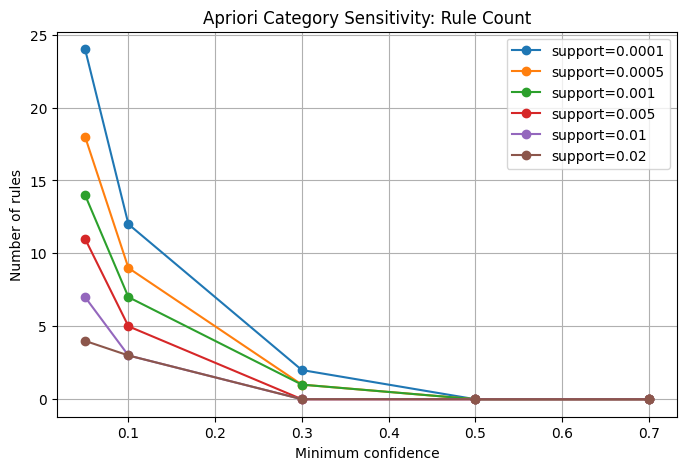

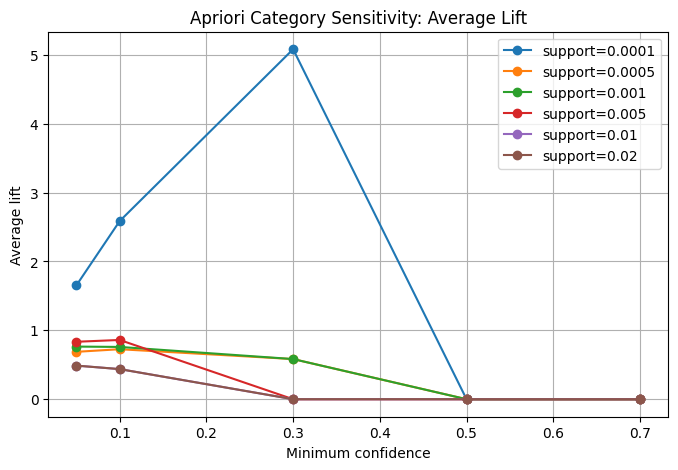

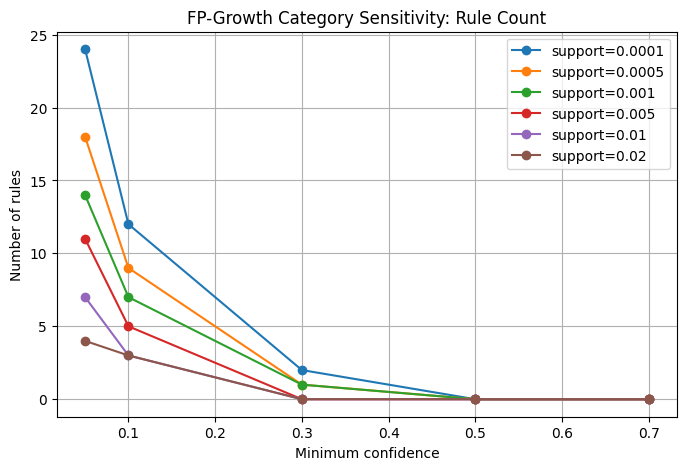

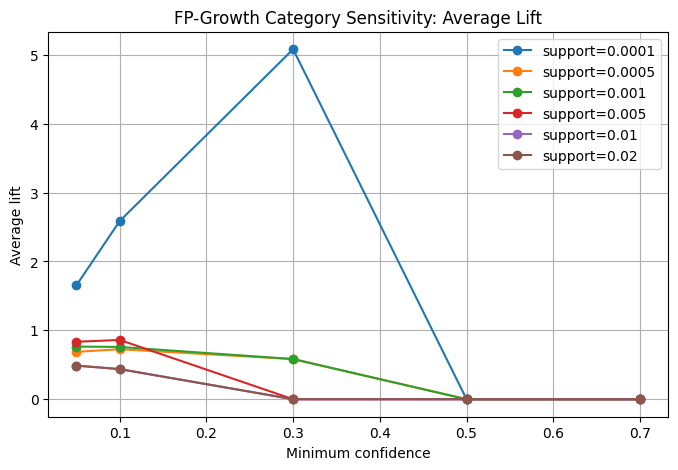

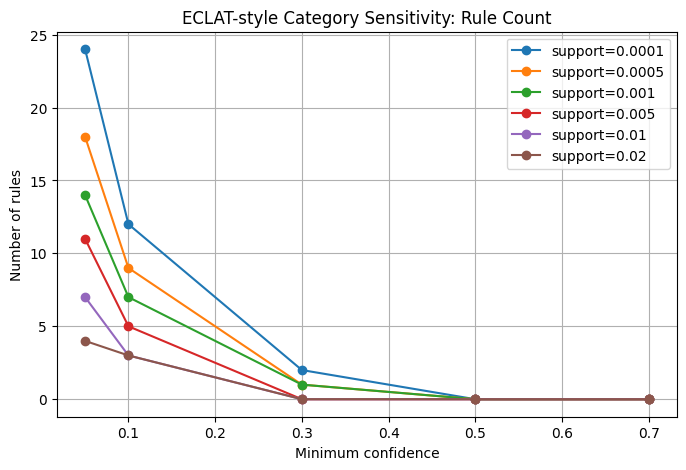

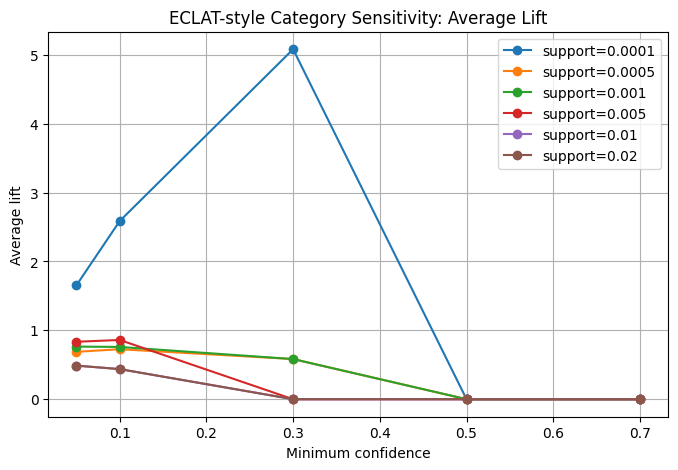

Saved sensitivity figures to: C:\Users\moh75\olist-recommendation-system\outputs\figures_multi_item


In [21]:
for alg_name in sensitivity_df["algorithm"].unique():
    temp_alg = sensitivity_df[sensitivity_df["algorithm"] == alg_name]

    plt.figure(figsize=(8, 5))
    for min_sup in sorted(temp_alg["min_support"].unique()):
        temp = temp_alg[temp_alg["min_support"] == min_sup].sort_values("min_confidence")
        plt.plot(temp["min_confidence"], temp["number_of_rules"], marker="o", label=f"support={min_sup}")

    plt.xlabel("Minimum confidence")
    plt.ylabel("Number of rules")
    plt.title(f"{alg_name} Category Sensitivity: Rule Count")
    plt.legend()
    plt.grid(True)
    filename = f"category_{alg_name.lower().replace('-', '_').replace(' ', '_')}_rule_count_sweep.png"
    plt.savefig(OUTPUT_FIGURES / filename, dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    for min_sup in sorted(temp_alg["min_support"].unique()):
        temp = temp_alg[temp_alg["min_support"] == min_sup].sort_values("min_confidence")
        plt.plot(temp["min_confidence"], temp["average_lift"], marker="o", label=f"support={min_sup}")

    plt.xlabel("Minimum confidence")
    plt.ylabel("Average lift")
    plt.title(f"{alg_name} Category Sensitivity: Average Lift")
    plt.legend()
    plt.grid(True)
    filename = f"category_{alg_name.lower().replace('-', '_').replace(' ', '_')}_avg_lift_sweep.png"
    plt.savefig(OUTPUT_FIGURES / filename, dpi=300, bbox_inches="tight")
    plt.show()

print("Saved sensitivity figures to:", OUTPUT_FIGURES.resolve())

## 9. Holiday EDA and seasonal decision

In [22]:
cat_holiday = category_df.merge(holiday_df, on="order_id", how="inner")
cat_holiday["basket_size"] = cat_holiday["category_groups"].apply(len)

holiday_counts = cat_holiday["is_holiday"].value_counts(dropna=False)
print("Holiday basket counts:")
print(holiday_counts)

print("\nBasket size by holiday flag:")
display(cat_holiday.groupby("is_holiday")["basket_size"].describe())

holiday_baskets = int(cat_holiday["is_holiday"].sum())
nonholiday_baskets = int((~cat_holiday["is_holiday"]).sum())

# Category mix table
cat_exploded = cat_holiday[["order_id", "is_holiday", "category_groups"]].explode("category_groups")
category_mix = (
    cat_exploded.groupby(["is_holiday", "category_groups"])
    .size()
    .reset_index(name="count")
)

category_mix["proportion"] = category_mix.groupby("is_holiday")["count"].transform(lambda x: x / x.sum())
category_mix = category_mix.rename(columns={"category_groups": "category_group"})

category_mix.to_csv(OUTPUT_RULES / "holiday_category_mix.csv", index=False)

# Chi-square test if possible
pivot_mix = category_mix.pivot_table(
    index="is_holiday",
    columns="category_group",
    values="count",
    fill_value=0
)

if pivot_mix.shape[0] == 2 and pivot_mix.shape[1] > 1:
    chi2, p_value, dof, expected = chi2_contingency(pivot_mix)
else:
    chi2, p_value, dof = np.nan, np.nan, np.nan

decision = "holiday" if (holiday_baskets >= 5000 and p_value < 0.05) else "seasonal"

holiday_eda_summary = pd.DataFrame({
    "metric": [
        "holiday_baskets",
        "nonholiday_baskets",
        "chi_square_p_value",
        "decision"
    ],
    "value": [
        holiday_baskets,
        nonholiday_baskets,
        p_value,
        decision
    ]
})

holiday_eda_summary.to_csv(OUTPUT_RULES / "holiday_eda_summary.csv", index=False)

print("\nHoliday baskets:", holiday_baskets)
print("Non-holiday baskets:", nonholiday_baskets)
print("Chi-square p-value:", p_value)
print("Decision:", decision)

display(holiday_eda_summary)
display(category_mix.head(20))

Holiday basket counts:
is_holiday
False    3138
True       52
Name: count, dtype: int64

Basket size by holiday flag:


,count,mean,std,min,25%,50%,75%,max
is_holiday,,,,,,,,
False,3138.0,1.133525,0.346692,1.0,1.0,1.0,1.0,3.0
True,52.0,1.211538,0.412384,1.0,1.0,1.0,1.0,2.0



Holiday baskets: 52
Non-holiday baskets: 3138
Chi-square p-value: 0.46720979164881926
Decision: seasonal


,metric,value
0,holiday_baskets,52
1,nonholiday_baskets,3138
2,chi_square_p_value,0.46721
3,decision,seasonal


,is_holiday,category_group,count,proportion
0,False,cama_mesa_banho,795,0.223503
1,False,construcao_ferramentas_jardim,25,0.007028
2,False,diversified_other,1685,0.473714
3,False,electronics_misc,89,0.025021
4,False,fashion_apparel,3,0.000843
5,False,fashion_bolsas_e_acessorios,108,0.030363
6,False,gifts_household,359,0.100928
7,False,livros_tecnicos,9,0.002530
8,False,moveis_decoracao,468,0.131572
9,False,music_homecomfort,16,0.004498


Mine condition-based rules. If holiday data is weak, the notebook uses seasonal mining.

In [23]:
condition_rule_tables = []

if decision == "holiday":
    print("Mining holiday vs non-holiday category rules.")

    for flag in [False, True]:
        condition_name = "holiday" if flag else "non_holiday"
        tx = cat_holiday.loc[cat_holiday["is_holiday"] == flag, "category_groups"].tolist()
        tx = clean_transactions(tx)

        if len(tx) < 100:
            continue

        onehot = one_hot_encode(tx, sparse=False)
        _, rules, runtime = run_mlxtend_rules(
            onehot,
            algorithm_name="fpgrowth",
            min_support=CAT_MIN_SUPPORT,
            min_confidence=CAT_MIN_CONFIDENCE,
            max_len=2
        )

        rules["condition"] = condition_name
        rules["algorithm"] = "FP-Growth"
        rules["basket_type"] = "category"
        condition_rule_tables.append(rules)

else:
    print("Holiday signal is weak, so mining seasonal category rules instead.")

    for season_name in sorted(cat_holiday["season"].dropna().unique()):
        tx = cat_holiday.loc[cat_holiday["season"] == season_name, "category_groups"].tolist()
        tx = clean_transactions(tx)

        if len(tx) < 100:
            continue

        onehot = one_hot_encode(tx, sparse=False)
        _, rules, runtime = run_mlxtend_rules(
            onehot,
            algorithm_name="fpgrowth",
            min_support=CAT_MIN_SUPPORT,
            min_confidence=CAT_MIN_CONFIDENCE,
            max_len=2
        )

        rules["condition"] = season_name
        rules["algorithm"] = "FP-Growth"
        rules["basket_type"] = "category"
        condition_rule_tables.append(rules)

        print(f"Season={season_name} | baskets={len(tx)} | rules={len(rules)} | runtime={round(runtime, 2)}s")

if len(condition_rule_tables) > 0:
    conditional_rules = pd.concat(condition_rule_tables, ignore_index=True)
    conditional_rules = sort_rules(conditional_rules)
else:
    conditional_rules = pd.DataFrame(columns=RULE_COLUMNS_FULL + ["condition", "algorithm", "basket_type"])

save_rules(conditional_rules, OUTPUT_RULES / "seasonal_category_rules.csv", list(conditional_rules.columns))
display(conditional_rules.head(20))

Holiday signal is weak, so mining seasonal category rules instead.
=== fpgrowth ===
Frequent itemsets: 28
Rules: 23
Runtime seconds: 0.01
Season=Inverno | baskets=997 | rules=23 | runtime=0.01s
=== fpgrowth ===
Frequent itemsets: 27
Rules: 19
Runtime seconds: 0.01
Season=Outono | baskets=947 | rules=19 | runtime=0.01s
=== fpgrowth ===
Frequent itemsets: 18
Rules: 11
Runtime seconds: 0.01
Season=Primavera | baskets=578 | rules=11 | runtime=0.01s
=== fpgrowth ===
Frequent itemsets: 25
Rules: 17
Runtime seconds: 0.01
Season=Verão | baskets=668 | rules=17 | runtime=0.01s
Saved: outputs\rules_multi_item\seasonal_category_rules.csv | rows=70


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,condition,algorithm,basket_type
0,frozenset({livros_tecnicos}),frozenset({construcao_ferramentas_jardim}),0.002006,0.009027,0.001003,0.500000,55.388889,1.0,0.000985,1.981946,0.983920,0.100000,0.495445,0.305556,Inverno,FP-Growth,category
1,frozenset({construcao_ferramentas_jardim}),frozenset({livros_tecnicos}),0.009027,0.002006,0.001003,0.111111,55.388889,1.0,0.000985,1.122743,0.990891,0.100000,0.109324,0.305556,Inverno,FP-Growth,category
53,frozenset({fashion_apparel}),frozenset({fashion_bolsas_e_acessorios}),0.001497,0.037425,0.001497,1.000000,26.720000,1.0,0.001441,inf,0.964018,0.040000,1.000000,0.520000,Verão,FP-Growth,category
54,frozenset({music_homecomfort}),frozenset({fashion_bolsas_e_acessorios}),0.002994,0.037425,0.001497,0.500000,13.360000,1.0,0.001385,1.925150,0.927928,0.038462,0.480560,0.270000,Verão,FP-Growth,category
55,frozenset({gifts_household}),frozenset({electronics_misc}),0.097305,0.026946,0.010479,0.107692,3.996581,1.0,0.007857,1.090491,0.830609,0.092105,0.082982,0.248291,Verão,FP-Growth,category
56,frozenset({electronics_misc}),frozenset({gifts_household}),0.026946,0.097305,0.010479,0.388889,3.996581,1.0,0.007857,1.477137,0.770549,0.092105,0.323015,0.248291,Verão,FP-Growth,category
42,frozenset({electronics_misc}),frozenset({gifts_household}),0.032872,0.160900,0.015571,0.473684,2.943973,1.0,0.010282,1.594291,0.682767,0.087379,0.372762,0.285229,Primavera,FP-Growth,category
43,frozenset({gifts_household}),frozenset({electronics_misc}),0.160900,0.032872,0.015571,0.096774,2.943973,1.0,0.010282,1.070749,0.786942,0.087379,0.066074,0.285229,Primavera,FP-Growth,category
2,frozenset({electronics_misc}),frozenset({gifts_household}),0.028084,0.114343,0.007021,0.250000,2.186404,1.0,0.003810,1.180876,0.558308,0.051852,0.153171,0.155702,Inverno,FP-Growth,category
3,frozenset({gifts_household}),frozenset({electronics_misc}),0.114343,0.028084,0.007021,0.061404,2.186404,1.0,0.003810,1.035499,0.612684,0.051852,0.034282,0.155702,Inverno,FP-Growth,category


## 10. Optional: inspect product dimension columns for readable product info

In [24]:
dim_product_columns = pd.read_sql("""
SELECT column_name
FROM information_schema.columns
WHERE table_name = 'dim_products'
ORDER BY ordinal_position
""", engine)

dim_product_columns

,column_name
0,product_id
1,product_category_name
2,product_category_name_english
3,product_weight_g
4,product_length_cm
5,product_height_cm
6,product_width_cm
7,product_photos_qty
8,category_group_id


This optional cell tries to load a product lookup table. It will not break the notebook if column names are different.

In [25]:
try:
    dim_products_preview = pd.read_sql("SELECT * FROM dim_products LIMIT 5", engine)
    display(dim_products_preview)
except Exception as e:
    print("Could not preview dim_products:", e)

,product_id,product_category_name,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_photos_qty,category_group_id
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,225,16,10,14,1,10
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,1000,30,18,20,1,6
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,154,18,9,15,1,10
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,371,26,4,26,1,8
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,625,20,17,13,4,10


## 11. Export ranked rules for M5

In [26]:
ranked_tables = []

ranked_tables.append(make_ranked_rules(rules_cat_apriori, "Apriori", "category", "all"))
ranked_tables.append(make_ranked_rules(rules_cat_fpgrowth, "FP-Growth", "category", "all"))
ranked_tables.append(make_ranked_rules(rules_cat_eclat, "ECLAT-style", "category", "all"))

ranked_tables.append(make_ranked_rules(rules_prod_apriori, "Apriori", "product", "all"))
ranked_tables.append(make_ranked_rules(rules_prod_fpgrowth, "FP-Growth", "product", "all"))
ranked_tables.append(make_ranked_rules(rules_prod_eclat, "ECLAT-style", "product", "all"))

# Condition-based rules, if any
if conditional_rules is not None and len(conditional_rules) > 0:
    if "condition" in conditional_rules.columns:
        for cond, part in conditional_rules.groupby("condition"):
            alg = part["algorithm"].iloc[0] if "algorithm" in part.columns else "FP-Growth"
            basket_type = part["basket_type"].iloc[0] if "basket_type" in part.columns else "category"
            ranked_tables.append(make_ranked_rules(part, alg, basket_type, cond))

all_ranked = pd.concat(ranked_tables, ignore_index=True)

# Remove impossible/empty rows
if len(all_ranked) > 0:
    all_ranked = all_ranked[
        (all_ranked["query_item"].notna()) &
        (all_ranked["recommended_item"].notna()) &
        (all_ranked["query_item"] != "") &
        (all_ranked["recommended_item"] != "")
    ].copy()

all_ranked.to_csv(OUTPUT_RULES / "ranked_rules_for_m5.csv", index=False)

print("Saved:", OUTPUT_RULES / "ranked_rules_for_m5.csv")
print("Ranked rules shape:", all_ranked.shape)
display(all_ranked.head(30))

Saved: outputs\rules_multi_item\ranked_rules_for_m5.csv
Ranked rules shape: (142, 10)


,query_item,recommended_item,rank,algorithm,basket_type,condition,segment_id,support,confidence,lift
0,cama_mesa_banho,moveis_decoracao,1,Apriori,category,all,None,0.024138,0.095297,0.639995
1,cama_mesa_banho,diversified_other,2,Apriori,category,all,None,0.017241,0.068069,0.126983
2,construcao_ferramentas_jardim,moveis_decoracao,1,Apriori,category,all,None,0.00094,0.12,0.805895
3,construcao_ferramentas_jardim,cama_mesa_banho,2,Apriori,category,all,None,0.000627,0.08,0.315842
4,construcao_ferramentas_jardim,diversified_other,3,Apriori,category,all,None,0.000627,0.08,0.14924
5,electronics_misc,gifts_household,1,Apriori,category,all,None,0.008464,0.293478,2.523438
6,electronics_misc,moveis_decoracao,2,Apriori,category,all,None,0.002194,0.076087,0.510984
7,electronics_misc,diversified_other,3,Apriori,category,all,None,0.00721,0.25,0.466374
8,electronics_misc,cama_mesa_banho,4,Apriori,category,all,None,0.003135,0.108696,0.429133
9,fashion_apparel,fashion_bolsas_e_acessorios,1,Apriori,category,all,None,0.000313,0.333333,9.57958


## 12. Final output summary

In [27]:
summary_rows = []

for p in sorted(OUTPUT_RULES.glob("*.csv")):
    try:
        df = pd.read_csv(p)
        summary_rows.append({
            "output": p.name,
            "rows": df.shape[0],
            "columns": df.shape[1]
        })
    except Exception as e:
        summary_rows.append({
            "output": p.name,
            "rows": "could not read",
            "columns": str(e)
        })

m3_output_summary = pd.DataFrame(summary_rows)
m3_output_summary.to_csv(OUTPUT_RULES / "m3_output_summary.csv", index=False)

print("=== OUTPUT FILES ===")
display(m3_output_summary)

print("\n=== FIGURE FILES ===")
for p in sorted(OUTPUT_FIGURES.glob("*")):
    print(p.name)

=== OUTPUT FILES ===


,output,rows,columns
0,basket_size_summary.csv,10,3
1,category_apriori_rules.csv,24,14
2,category_eclat_rules.csv,24,7
3,category_fpgrowth_rules.csv,24,14
4,holiday_category_mix.csv,16,4
5,holiday_eda_summary.csv,4,2
6,multi_item_filter_summary_from_db.csv,7,2
7,product_apriori_rules.csv,0,14
8,product_eclat_rules.csv,0,7
9,product_fpgrowth_rules.csv,0,14



=== FIGURE FILES ===
category_apriori_avg_lift_sweep.png
category_apriori_rule_count_sweep.png
category_eclat_style_avg_lift_sweep.png
category_eclat_style_rule_count_sweep.png
category_fp_growth_avg_lift_sweep.png
category_fp_growth_rule_count_sweep.png


In [28]:
pd.read_sql("""
SELECT column_name
FROM information_schema.columns
WHERE table_name = 'dim_category_group'
ORDER BY ordinal_position
""", engine)

,column_name
0,group_id
1,group_name
2,description


In [29]:
product_meta = pd.read_sql("""
    SELECT 
        p.product_id,
        p.product_category_name,
        p.product_category_name_english,
        g.group_name AS category_group
    FROM dim_products p
    LEFT JOIN dim_category_group g
        ON p.category_group_id = g.group_id
""", engine)

product_meta.head()

,product_id,product_category_name,product_category_name_english,category_group
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,diversified_other
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,moveis_decoracao
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,diversified_other
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,gifts_household
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,diversified_other


In [30]:
ranked = pd.read_csv(OUTPUT_RULES / "ranked_rules_for_m5.csv")

readable = ranked.merge(
    product_meta,
    left_on="query_item",
    right_on="product_id",
    how="left"
).rename(columns={
    "product_category_name_english": "query_product_category_english",
    "product_category_name": "query_product_category_pt",
    "category_group": "query_category_group"
}).drop(columns=["product_id"])

readable = readable.merge(
    product_meta,
    left_on="recommended_item",
    right_on="product_id",
    how="left"
).rename(columns={
    "product_category_name_english": "recommended_product_category_english",
    "product_category_name": "recommended_product_category_pt",
    "category_group": "recommended_category_group"
}).drop(columns=["product_id"])

readable.to_csv(OUTPUT_RULES / "ranked_rules_for_m5_readable.csv", index=False)

readable.head(20)

,query_item,recommended_item,rank,algorithm,basket_type,condition,segment_id,support,confidence,lift,query_product_category_pt,query_product_category_english,query_category_group,recommended_product_category_pt,recommended_product_category_english,recommended_category_group
0,cama_mesa_banho,moveis_decoracao,1,Apriori,category,all,NaN,0.024138,0.095297,0.639995,NaN,NaN,NaN,NaN,NaN,NaN
1,cama_mesa_banho,diversified_other,2,Apriori,category,all,NaN,0.017241,0.068069,0.126983,NaN,NaN,NaN,NaN,NaN,NaN
2,construcao_ferramentas_jardim,moveis_decoracao,1,Apriori,category,all,NaN,0.000940,0.120000,0.805895,NaN,NaN,NaN,NaN,NaN,NaN
3,construcao_ferramentas_jardim,cama_mesa_banho,2,Apriori,category,all,NaN,0.000627,0.080000,0.315842,NaN,NaN,NaN,NaN,NaN,NaN
4,construcao_ferramentas_jardim,diversified_other,3,Apriori,category,all,NaN,0.000627,0.080000,0.149240,NaN,NaN,NaN,NaN,NaN,NaN
5,electronics_misc,gifts_household,1,Apriori,category,all,NaN,0.008464,0.293478,2.523438,NaN,NaN,NaN,NaN,NaN,NaN
6,electronics_misc,moveis_decoracao,2,Apriori,category,all,NaN,0.002194,0.076087,0.510984,NaN,NaN,NaN,NaN,NaN,NaN
7,electronics_misc,diversified_other,3,Apriori,category,all,NaN,0.007210,0.250000,0.466374,NaN,NaN,NaN,NaN,NaN,NaN
8,electronics_misc,cama_mesa_banho,4,Apriori,category,all,NaN,0.003135,0.108696,0.429133,NaN,NaN,NaN,NaN,NaN,NaN
9,fashion_apparel,fashion_bolsas_e_acessorios,1,Apriori,category,all,NaN,0.000313,0.333333,9.579580,NaN,NaN,NaN,NaN,NaN,NaN


## 13. M5 handoff file for the multi-item experiment

This saves `ranked_rules_for_m5_with_segments.csv` in the multi-item output folder so M5 can run using the same expected filename.

In [31]:
# For this controlled experiment, create a with-segments handoff file even if per-segment rules are not regenerated.
# M5 can then use the same expected filename safely.
base_ranked_path = OUTPUT_RULES / "ranked_rules_for_m5.csv"
with_segments_path = OUTPUT_RULES / "ranked_rules_for_m5_with_segments.csv"

base_ranked = pd.read_csv(base_ranked_path)
if "segment_id" not in base_ranked.columns:
    base_ranked["segment_id"] = np.nan

base_ranked.to_csv(with_segments_path, index=False)
print("Saved M5 handoff file:", with_segments_path)
print("Rows:", len(base_ranked))


Saved M5 handoff file: outputs\rules_multi_item\ranked_rules_for_m5_with_segments.csv
Rows: 142
